In [ ]:
#AI Usage Disclosure:
# Used Claude to... change graph colors (vt scheme) and debugging my graph by fixing overlapping labels (rotation and font size)
# - All interpretation, analysis, and written commentary is my own work.

In [ ]:
Final_Exam = '''Step 1. Choose your API
Choose one of the following APIs. Provide a comment with the endpoint URL and a link to its documentation.

API	Endpoint	Notes
USGS Earthquakes	https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=...&endtime=...&minmagnitude=4	Cleanest fit. Plenty of quantitative and qualitative fields. Expect missing values; handle them in Step 5.
Open-Meteo Historical Weather	https://archive-api.open-meteo.com/v1/archive	Lots of quantitative variables. You will need to engineer your qualitative variables (e.g., season, month name, weekend vs. weekday from the date column).
PokéAPI	https://pokeapi.co/api/v2/pokemon?limit=200 plus per-Pokémon detail calls	Fun, clean data, but requires a loop over detail endpoints to assemble the dataframe.
World Bank Indicators	https://api.worldbank.org/v2/country/all/indicator/{indicator_code}?format=json&per_page=20000	You will need to call multiple indicator endpoints and merge them on country and year. Most ambitious option.
Important: If you used one of these APIs for Assignment 3, you may not use it for the final. Pick a different one from the list. This requirement is to ensure you are demonstrating new work, not resubmitting a previous pipeline with extra steps. If you are unsure whether your Assignment 3 API counts, ask before you start.

Step 2. Send the request
Send a request to your chosen endpoint. Verify the server status is okay (status code 200). Store the response in a variable.

Step 3. Build the dataframe
Convert the API response (JSON) to a Pandas dataframe. For nested responses (USGS, World Bank, PokéAPI), flatten the relevant section into tabular form.

Step 4. Describe and fix datatypes
Invoke .describe() on the dataframe. Convert any mismatched datatypes to their proper datatypes (e.g., epoch milliseconds to datetime, numeric strings to floats). Invoke .describe(include='all') a second time after corrections. With a comment, explain what each column represents.

Step 5. Explore the data
With comments, answer: How many rows and columns? Are there missing values, and how did you handle them? Are there any obvious data quality issues?

Step 6. Identify your dependent variable
Your dependent variable (DV) must be quantitative. With a comment, explain what the DV represents, its units, and why you chose it as the outcome of interest.

Step 7. Identify ten independent variables
At least seven must be quantitative; at least two must be qualitative. (Open-Meteo users: engineered qualitative variables count.) With a comment, justify each choice: why do you expect this variable to relate to the DV?

Step 8. Distribution plots
Create a distribution plot for every column in the dataframe as a single figure with subplots: histograms for quantitative columns, bar charts of value counts for qualitative columns. Save as lastname_distributions.png.

8a. With a comment, identify every variable whose skewness has |skew| > 1 and note whether the skew is positive or negative.
Step 9. Box-and-whisker plot of the DV
Create a box-and-whisker plot of your dependent variable. Output as lastname_boxplot.png.

9a. With a comment, describe the median, IQR, and any outliers. Note whether the distribution looks symmetric, skewed, or heavy-tailed.
Step 10. Correlation heatmap
Create a correlation heatmap of all quantitative variables (DV plus quantitative IVs). Output as lastname_correlation.png.

10a. With a comment, identify the IV most strongly correlated with the DV (positive or negative), and flag any pairs of IVs with |r| > 0.8 (multicollinearity warning for Step 14).
Step 11. Relationship plots
Create a single figure with ten subplots showing the relationship between each IV and the DV: scatter plots for quantitative IVs, box or violin plots for qualitative IVs. Output as lastname_relationships.png.

11a. With a comment block, briefly describe what each panel shows and whether a relationship appears to exist.
Step 12. Train/test split
Split the data 70/30 into training and testing sets using train_test_split with a fixed random_state.

Step 13. Univariate regressions
Fit a simple linear regression of the DV on each IV individually (ten separate models) using the training set. Record the test set R² for each. With a comment, state which single variable predicts the DV best and report its test R².

Step 14. Multivariate regression
Fit a multivariate linear regression using all ten IVs on the training set. (One-hot encode your qualitative variables.) Evaluate on the test set and report R², RMSE, and each variable's coefficient. Plot predicted vs. actual values for the test set. Output as lastname_multivariate.png.

14a. With a comment, explain: Did the multivariate model outperform the best univariate model? Which coefficients were largest in magnitude (standardize the inputs first if you want to compare them fairly)? Were any signs surprising given your expectations from Step 7? If you flagged multicollinearity in Step 10a, did it affect any coefficients? What does the model tell you about the DV?
Step 15. Write the summary file
Output a text file named lastname_stats.txt summarizing the dataset for someone unfamiliar with it. Include:

The describe() summary
Your DV and IV choices with justifications
Skewness findings from Step 8a
Strongest correlations from Step 10a
The univariate R² results and which IV predicted best
The multivariate model's R², RMSE, coefficients, and your interpretation
Evaluation
Your script will be run from the command line using your submitted *.py file. Successful completion will generate the following files without any intervention from the evaluator:

lastname_distributions.png
lastname_boxplot.png
lastname_correlation.png
lastname_relationships.png
lastname_multivariate.png
lastname_stats.txt
Submissions reusing an Assignment 3 API will receive a zero.

AI Usage Policy
You may use AI tools (ChatGPT, Claude, Copilot, Cursor, etc.) for code generation and debugging. This includes:

Writing boilerplate (API requests, JSON flattening, plotting code, train/test splits)
Debugging errors
Looking up syntax, library methods, or parameter names
Refactoring or cleaning up code you've written
You may not use AI tools for interpretation or analysis. The following must be written entirely in your own words, based on your own examination of the data:

The justification for your dependent variable (Step 6)
The justifications for each of your ten independent variables (Step 7)
The skewness commentary (Step 8a)
The boxplot interpretation (Step 9a)
The correlation findings (Step 10a)
The relationship descriptions (Step 11a)
The multivariate model interpretation (Step 14a)
The summary content of lastname_stats.txt (Step 15)
Disclosure requirement
Include a comment block at the top of your .py file listing which AI tools you used and what you used them for. Example:

# AI Usage Disclosure:
# - Used ChatGPT to debug a KeyError when flattening the USGS 'properties' field.
# - Used Claude to remind me of the syntax for sklearn's train_test_split.
# - All interpretation, analysis, and written commentary is my own work.
Failure to disclose AI usage that is later identified will be treated as academic dishonesty.

Accountability
I reserve the right to ask you to explain any portion of your submitted code or analysis in a brief follow-up conversation. If you cannot explain what your code does, why you made a particular analytical choice, or what your interpretation comments mean, you will receive a zero for the final exam and be referred for academic dishonesty charges. Plan accordingly: do not submit code or analysis you do not understand.

How AI-generated interpretation is identified
AI-written analysis tends to be generic, hedged, and disconnected from the actual numbers in your output. It describes what a correlation heatmap generally shows rather than what yours shows. It uses phrases like "this suggests a potential relationship that warrants further investigation" instead of naming the specific variables and the specific R² values from your script. Interpretation that does not reference your actual results (your actual coefficients, your actual skewness values, your actual best predictor) will result in a zero for the final exam and a referral for academic dishonesty charges, regardless of whether AI was used.'''

In [ ]:
#PokeAPI - API of the pokedex
#Documentation: https://pokeapi.co/
#Endpoint: https://pokeapi.co/api/v2/pokemon?limit=200

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

#sklearn cheatsheet
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
url = 'https://pokeapi.co/api/v2/pokemon?' #removed the 200 limit to stay within generation 1
parameter = {"limit":151} #limited to generation 1: kanto
response = requests.get(url, params= parameter)
print(response.status_code)
results = response.json()

200


In [ ]:
pokeDexList = []

for pokemon in results["results"]:
  pokemonName = pokemon["name"]
  info = requests.get(pokemon["url"]).json()
  types = []
  for elementType in info["types"]:
    types.append(elementType["type"]["name"])
  primaryTyping = types[0]
  stats={}
  for battleStats in info["stats"]:
    stats[battleStats["stat"]["name"]] = battleStats["base_stat"]

  pokeDexList.append({
      'name': pokemonName,
      'id': info ["id"],
      "primary_typing": primaryTyping,
      "secondary_typing": types[1] if len(types) > 1 else None, #checks if theres a second type and returns none if not
      'height': info['height'],
      'weight': info['weight'],
      'base_experience': info["base_experience"],
      'attack': stats.get("attack"),
      'special_attack': stats.get("special-attack"),
      'defense': stats.get("defense"),
      'special_defense': stats.get('special-defense'),
      'hp': stats.get("hp")
  })
df = pd.DataFrame(pokeDexList)
df['secondary_type'] = 'single'
df.loc[df['secondary_typing'].notna(), 'secondary_type'] = 'double' #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.notna.html
print(df.head())

         name  id primary_typing  ... special_defense  hp  secondary_type
0   bulbasaur   1          grass  ...              65  45          double
1     ivysaur   2          grass  ...              80  60          double
2    venusaur   3          grass  ...             100  80          double
3  charmander   4           fire  ...              50  39          single
4  charmeleon   5           fire  ...              65  58          single

[5 rows x 13 columns]


In [ ]:
print(df.describe())
df['base_experience'] = pd.to_numeric(df['base_experience'], errors='coerce')   #Documentation: https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
df['id'] = df['id'].astype(int)                                       #Turns into an integer
df['primary_typing'] = df['primary_typing'].astype('category')
print(df.describe(include = 'all'))                            #Documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html
# Column meanings:
# ID: Identification number of the given pokemon within the Dex
# Primary Typing: Main type of the pokemon
# Secondary Typing: If the pokemon has 1 or 2 types
# Height: Pokemon's height based on pokedex entries
# Weight: Pokemon's weight based on pokedex entries
# Base_experience: Pokemon's base amount of experience dropped when defeated
# Attack: Pokemon's base attack stat
# Special_attack: Pokemon's base special attack stat
# Defense: Pokemon's base defense stat
# Special_defense: Pokemon's base special defense stat
# Hp: Pokemon's base HP stat

               id      height  ...  special_defense          hp
count  151.000000  151.000000  ...       151.000000  151.000000
mean    76.000000   11.947020  ...        66.086093   64.211921
std     43.734045    9.626206  ...        24.208797   28.590117
min      1.000000    2.000000  ...        20.000000   10.000000
25%     38.500000    7.000000  ...        49.000000   45.000000
50%     76.000000   10.000000  ...        65.000000   60.000000
75%    113.500000   15.000000  ...        80.000000   80.000000
max    151.000000   88.000000  ...       125.000000  250.000000

[8 rows x 9 columns]
             name          id  ...          hp secondary_type
count         151  151.000000  ...  151.000000            151
unique        151         NaN  ...         NaN              2
top     bulbasaur         NaN  ...         NaN         single
freq            1         NaN  ...         NaN             84
mean          NaN   76.000000  ...   64.211921            NaN
std           NaN   43.734045 

In [ ]:
df = df.dropna(subset=["base_experience"]) #Drops any base_experience listed as na or nan if the limit were to change
print(df.describe())
print(df.shape)
#  How many rows and columns? There are 151 rows and 13 columns.
#  Are there missing values, and how did you handle them? When I changed the limiter I created to 1300, around the 800 mark there were errors within "base_experience", to handle these I used .dropna to get rid of any NA or NaN in the case the limiter is changed.
#  Are there any obvious data quality issues? Nothing shown by the output, there are some issues when the limiter is set higher but within the basic 151 the data is very clean.

               id      height  ...  special_defense          hp
count  151.000000  151.000000  ...       151.000000  151.000000
mean    76.000000   11.947020  ...        66.086093   64.211921
std     43.734045    9.626206  ...        24.208797   28.590117
min      1.000000    2.000000  ...        20.000000   10.000000
25%     38.500000    7.000000  ...        49.000000   45.000000
50%     76.000000   10.000000  ...        65.000000   60.000000
75%    113.500000   15.000000  ...        80.000000   80.000000
max    151.000000   88.000000  ...       125.000000  250.000000

[8 rows x 9 columns]
(151, 13)


In [ ]:
# Quant Fields:
# HP: I think higher HP leads to more combat time meaning higher base experience
# Attack: I believe higher Attack usually means the pokemon is evolved or from a higher level area (in the games), which tend to have higher base experience
# Defense: I think the relationship will be weak but will exist, this is because defense is high on weaker pokemon like metapod, though there are strong pokemon that have high defense aswell.
# SP_attack: I believe higher Special Attack leads to higher base experience and will have a similar result to strength
# SP_defense: I believe higher Special Defense leads to higher base experience and will have similar results to defense.
# Weight: I believe heavier pokemon are often stronger, meaning they would have a higher base experience, but there will be outliers like Ryhorn.
# Height: I believe taller pokemon tend to be stronger therefore having a higher base experience
# ID: I believe pokemon who have higher ID numbers are going to have high base experience since legendary/mythical pokemon have larger ID numbers

# Qual Fields:
# Primary Type: I think certain types on average have a higher base experience than others such as flying which is the typing of all the Kanto legendaries
# Secondary Type: I expect that Pokemon with two types tend to have a higher base experience than pokemon with only 1 type becuase 2 types add more versatility

In [ ]:
#Dependent variable: base_experience
# Base experience is the amount of exp dropped when the pokemon is defeated.
# The reason I chose this stat is because I believe that it equates to the pokemons value.
# Pokemon who are stronger tend to drop more exp, such as legendaries and mythicals, so I think that overall stats (attack, hp, special attack, etc) decide the pokemon's base experience.

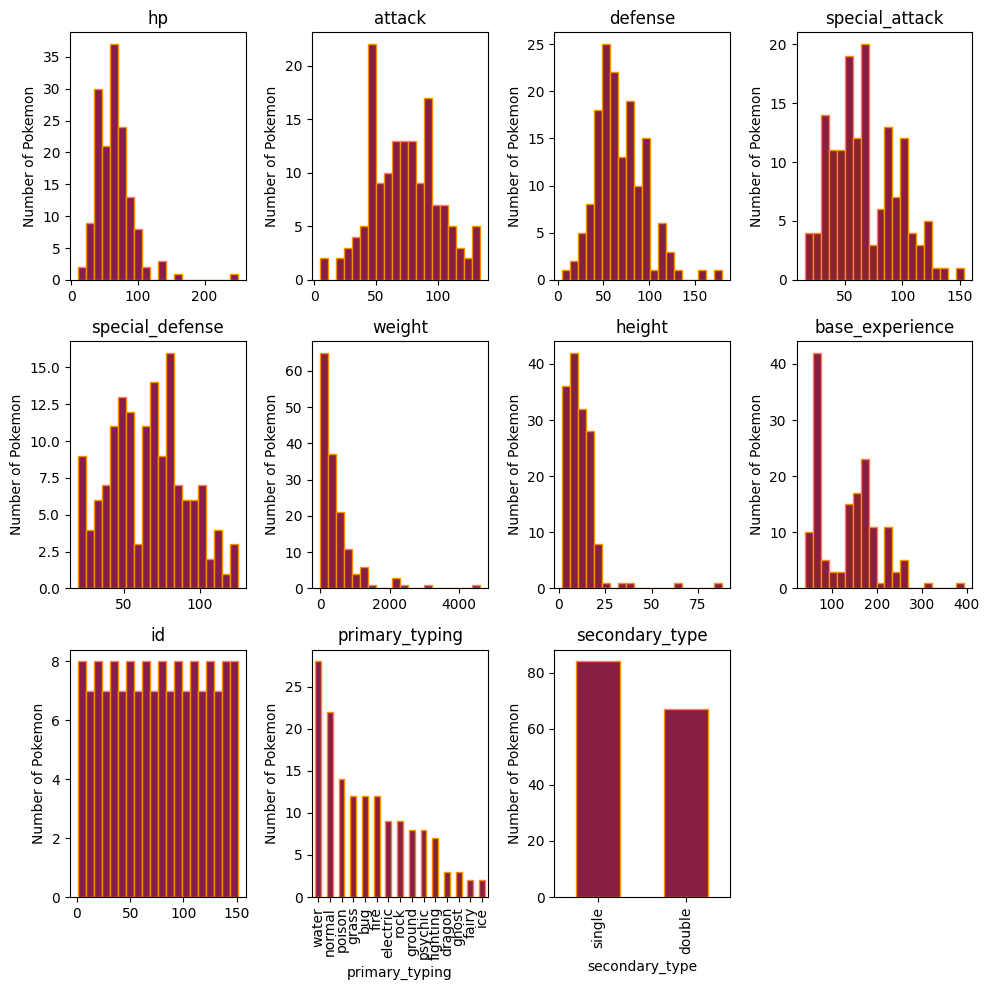

hp: skew = 2.31(positive)
weight: skew = 3.55(positive)
height: skew = 4.66(positive)


In [ ]:
#Reference: bivariate_linear_modeling_examples.py in "code from class" folder section 16
quantitativeColumn = ['hp', 'attack', 'defense', 'special_attack', 'special_defense', 'weight', 'height', 'base_experience', 'id']
qualitativeColumn = ['primary_typing', 'secondary_type']
totalColumns = quantitativeColumn + qualitativeColumn

fig, ax = plt.subplots(3, 4, figsize=(10, 10)) #3 rows, 4 columns, 10x10
ax = ax.flatten()
for indexNumber, column in enumerate(totalColumns):
  if column in quantitativeColumn:
    ax[indexNumber].hist(df[column], bins=20, color='#861f41', edgecolor= 'darkorange')
  else:
    df[column].value_counts().plot(kind='bar', ax=ax[indexNumber], color='#861f41', edgecolor='darkorange')
  ax[indexNumber].set_title(column)
  ax[indexNumber].set_ylabel('Number of Pokemon')
for emptyPlots in range(len(totalColumns), len(ax)):
  fig.delaxes(ax[emptyPlots])
plt.tight_layout()
plt.savefig('Peot_distributions.png')
plt.show()

for column in quantitativeColumn:
  skewness = df[column].skew()
  if abs(skewness) > 1:
    direction = 'positive' if skewness > 0 else 'negative'
    print(column + ": skew = " + str(round(skewness, 2)) + "(" + direction + ")")

#There were 3 variables that had a clear skew
# hp: skew was 2.31 which is a positive skew, most pokemon fall between approximately 10 and 100 hp with a few outliers
# weight: skew was 3.55 which is a positive skew, most pokemon fall between 0 and 1500 hectograms with a few outliers showing up between 2000 and 4500
# Height: skew was 4.66 which is a positive skew, most pokemon are on the shorter side falling between 0 and 25 decimetres


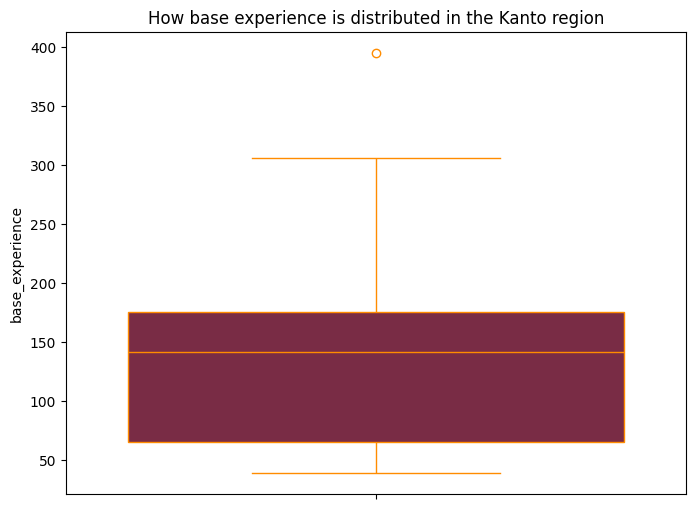

count    151.000000
mean     135.052980
std       67.719794
min       39.000000
25%       65.000000
50%      142.000000
75%      176.000000
max      395.000000
Name: base_experience, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=df, y= 'base_experience', color='#861f41', linecolor='darkorange', ax=ax)
plt.title('How base experience is distributed in the Kanto region')
plt.savefig('Peot_boxplot.png')
plt.show()
print(df['base_experience'].describe())

#Based on the boxplot:
# The median is 142 meaning more than half of pokemon from kanto drop at most 142 exp
# The IQR is 176 - 65 = 111, this indicates that there is moderately high variability for the base exp drops for the middle 50% of pokemon
# There is only 1 significant outlier who has a base exp drop of 395, this tells me that it is likely a legendary pokemon like Mew, MewTwo, or one of the legendary birds
# The top whisker is much larger than the bottom whisker, leading me to believe that the data is skewed more to the right

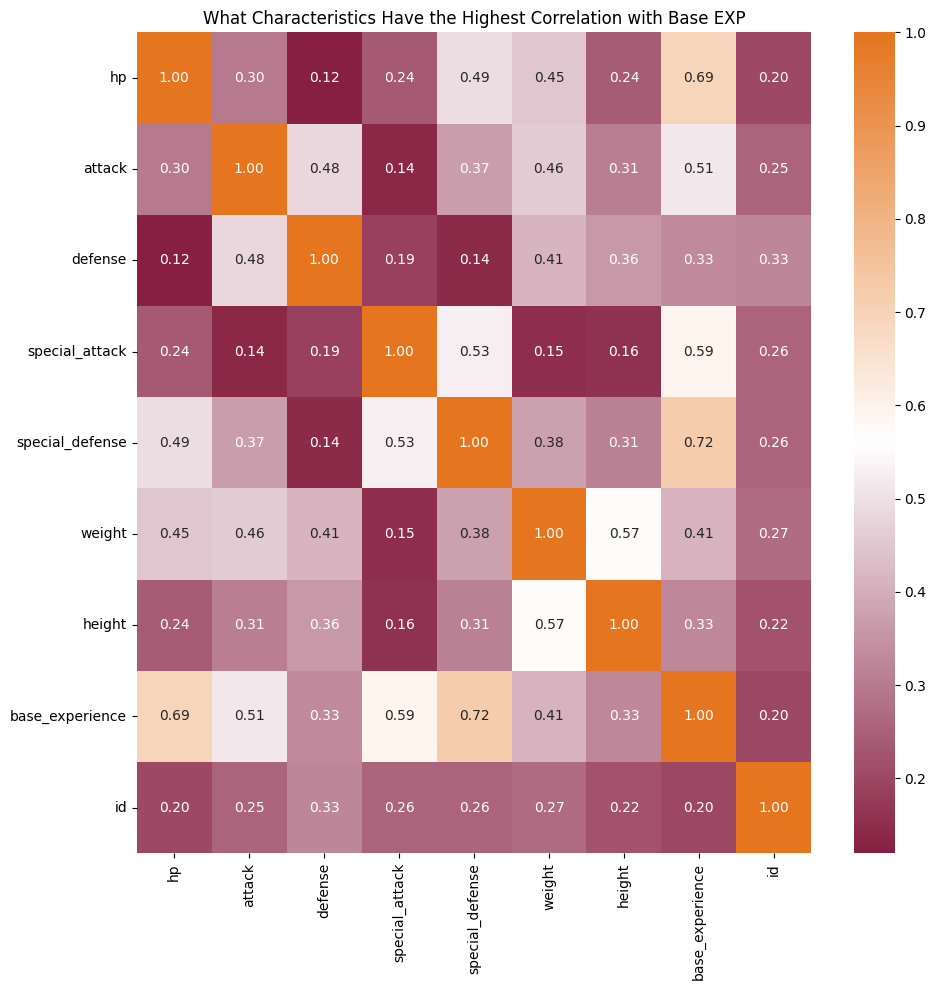

In [ ]:
vt_cmap = LinearSegmentedColormap.from_list('vt', ['#861F41', '#FFFFFF', '#E5751F']) #changes the colors of the graph to VT theme
fig, ax = plt.subplots(figsize=(10,10))
correlation = df[quantitativeColumn].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', ax=ax, cmap=vt_cmap)  #Reference: bivariate_linear_modeling_examples.py in "code from class" section 12
ax.set_title('What Characteristics Have the Highest Correlation with Base EXP')
plt.tight_layout()
plt.savefig('Peot_Correlation.png')
plt.show()
#Heatmap Analysis
# The IV that lines up with the dependent variable most strongly correlated with base EXP is special defense, with a correlation of 0.72.
# There are no independent variables with a correlation |r| > 0.80

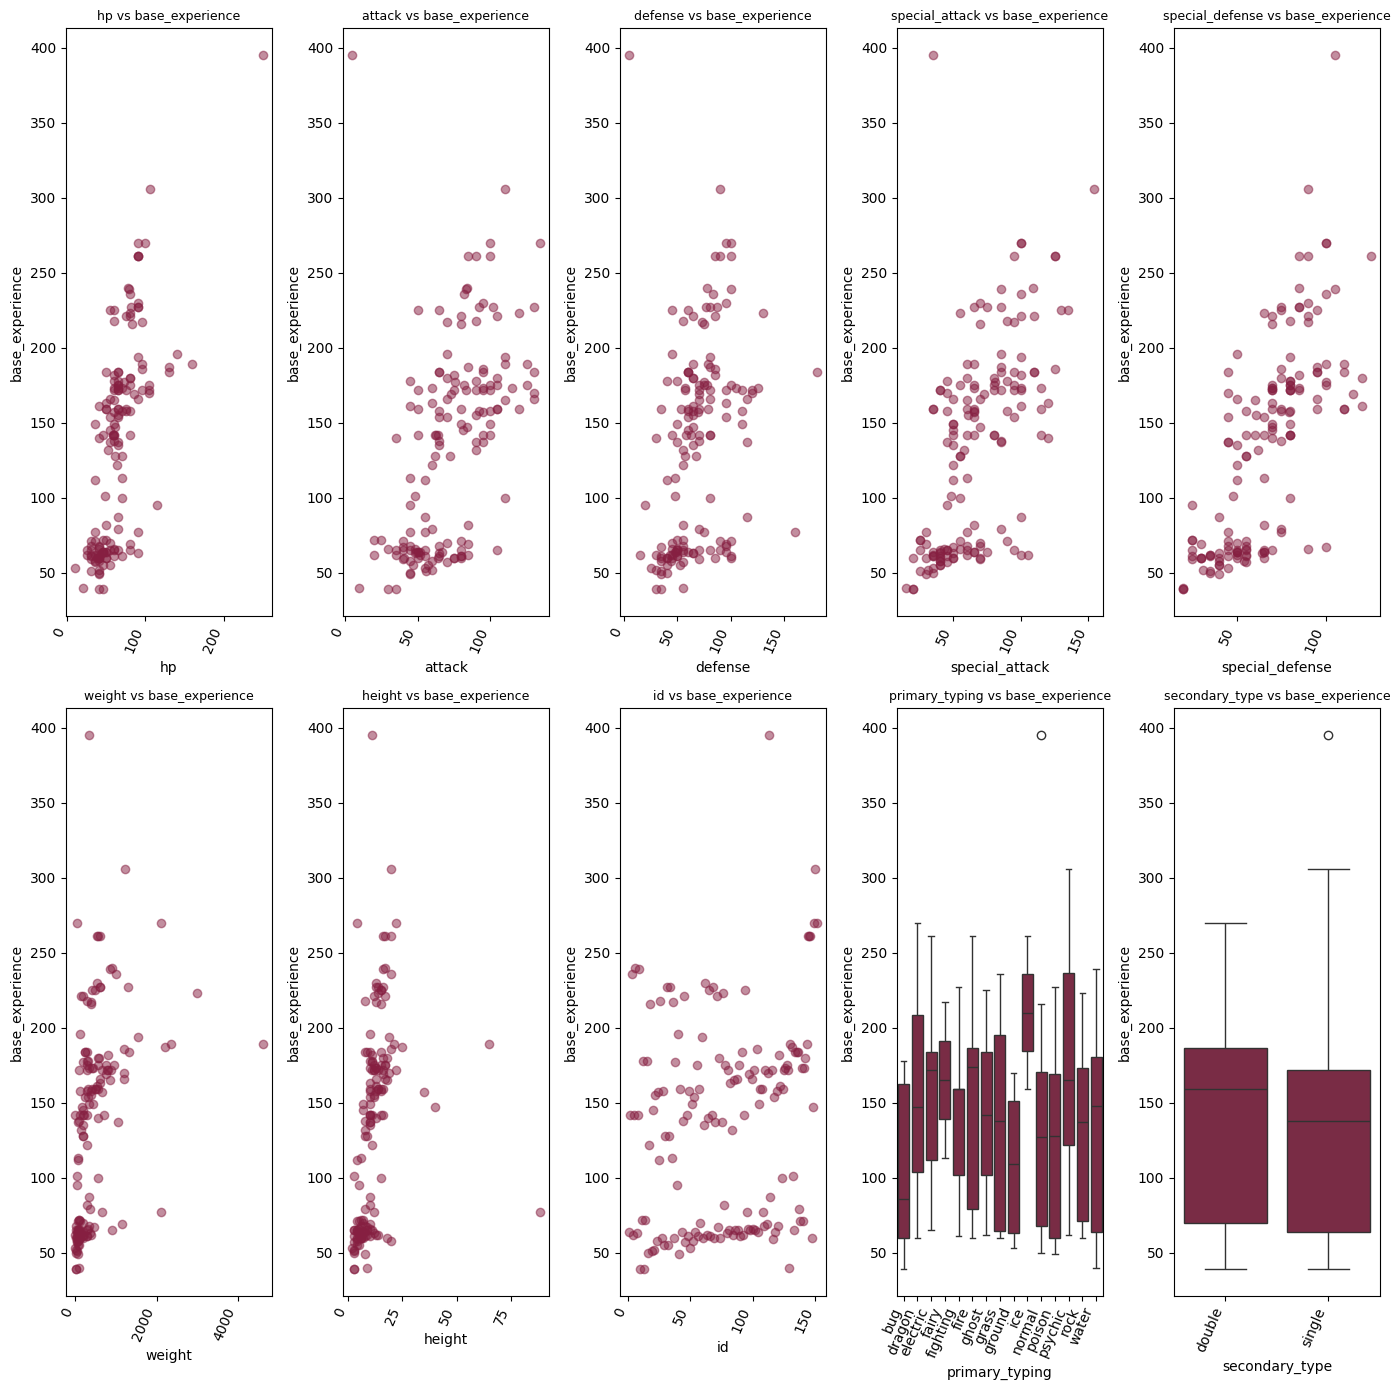

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(14,14))
ax = ax.flatten()
noBaseExp = quantitativeColumn.copy()
noBaseExp.remove('base_experience')
for indexNumber, column in enumerate(noBaseExp + qualitativeColumn):
  if column in noBaseExp:
    ax[indexNumber].scatter(df[column], df['base_experience'], color='#861F41', alpha=0.5)
    ax[indexNumber].set_ylabel('base_experience')
  else:
    sns.boxplot(data=df, x=column, y='base_experience', ax=ax[indexNumber], color = '#861F41')
  ax[indexNumber].set_xlabel(column)
  ax[indexNumber].set_title(column + ' vs base_experience', fontsize=9)
  for label in ax[indexNumber].get_xticklabels():
    label.set_rotation(67)
    label.set_ha('right')

plt.tight_layout()
plt.savefig('Peot_relationships.png')
plt.show()

# Relationships
# HP: The relationship between HP and Base Experience is positive but weak. As HP increases, base experience slightly increases. However, there are apparent outliers who have significantly more HP and base EXP.
# Attack: The relationship between Attack and Base Experience is positive. As attack increases, base experience usually increases. Although, there are some outliers who have less than 50 attack and sit near the 400 base EXP mark.
# Defense: The relationship between Defense and Base Experience is positive, but weak. Similarly to the rest of the variables, there is an outlier pulling against the noticeable trend.
# Special Attack: The relationship between Special Attack and Base Experience is positive, but average, similar to attack. There are 2 notable outliers, one has very high base exp, but low special attack. The other has both high base exp and special attack. Despite these outliers the trend is still clearly positive.
# Special Defense: There is a strong positive relationship with a very noticeable trend. Within the special defense graph, there are outliers but nothing major pulling against the trend. This suggests special defense may be a strong predictor of base experience.
# Weight: The relationship appears extremely weak due to significant outliers reaching the 2000-5000 mark and squishing the data towards the 0 mark. Removing the outliers would make the relationship appear significantly stronger (for example, heavy pokemon like Snorlax).
# Height: Similarly to weight, the relationship appears weak from extreme outliers and without them would likely appear stronger. This is due to the outliers stretching the axis and flattening the data towards the 0 mark.
# ID: There's a decently strong positive relationship here. This checks out since pokemon with higher ID numbers tend to be legendary or pseudo-legendary, and these pokemon often drop more exp.
# Primary Typing: There is a visible difference in the medians across all the types, suggesting that certain types do have a higher exp yield than others. Types that tend to be stronger in gen 1, such as ice, psychic, and dragon, had higher base exp drops, whereas types like bug and poison (who are encountered in lower level areas) sit with the lowest median. Most pokemon sit between the 125-200 range, suggesting that primary typing has a weak, positive relationship with base EXP.
# Secondary Typing: Pokemon who have a second type have a higher median than pokemon with a single type, suggesting that pokemon with 2 types tend to have a higher base EXP.


In [ ]:
x_axis = df[noBaseExp + qualitativeColumn]
y_axis = df['base_experience']
xTrain, xTest, yTrain, yTest = train_test_split(x_axis, y_axis, test_size= 0.3, random_state= 151)
print("Set size for train:", len(xTrain))
print("Set size for test:", len(xTest))

Set size for train: 105
Set size for test: 46


In [ ]:
resultsR2 = {} #empty dict for r2

for column in noBaseExp + qualitativeColumn: #loops evey IV
  if column in qualitativeColumn:
    xTrainColumn = pd.get_dummies(xTrain[[column]])     # Documentation: https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
    xTestColumn = pd.get_dummies(xTest[[column]])       # assigns a value of 0 or 1 to each qualitative variable so they can be referenced in the model
  else:
    xTrainColumn = xTrain[[column]]  #calls a value from the quant colum
    xTestColumn = xTest[[column]]

  modelforLR = LinearRegression()
  modelforLR.fit(xTrainColumn, yTrain)        # Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html , Trains model on given data
  yPrediction = modelforLR.predict(xTestColumn)  # model predicts using test data
  r2Value = r2_score(yTest, yPrediction)
  resultsR2[column] = r2Value
  print(column+ ':R2=' + str(round(r2Value, 4)))

high = max(resultsR2, key= resultsR2.get)
print("Highest predictor:" + high + "with R2 =" + str(round(resultsR2[high], 4)))

# Which variable predicts the DV the best? Based on the results the highest predictor of base exp was special defense with an R2 of 0.5491

hp:R2=0.4873
attack:R2=0.1061
defense:R2=-0.1371
special_attack:R2=0.2343
special_defense:R2=0.5491
weight:R2=0.0446
height:R2=-0.3338
id:R2=0.0278
primary_typing:R2=-0.2828
secondary_type:R2=-0.2268
Highest predictor:special_defensewith R2 =0.5491


r2: 0.6453
rmse: 46.6374
coefficients:
hp                          0.465488
attack                      0.746366
defense                     0.420425
special_attack              0.952811
special_defense             0.694225
weight                      0.002785
height                      0.326166
id                         -0.322365
primary_typing_bug          6.739906
primary_typing_dragon       0.563268
primary_typing_electric    15.316561
primary_typing_fairy        5.546021
primary_typing_fighting    -1.520473
primary_typing_fire       -14.522817
primary_typing_ghost        9.636333
primary_typing_grass      -16.419264
primary_typing_ground      -9.221335
primary_typing_ice         21.789052
primary_typing_normal       9.374519
primary_typing_poison      -8.375303
primary_typing_psychic    -11.654470
primary_typing_rock         1.019476
primary_typing_water       -8.271474
secondary_type_double       0.516887
secondary_type_single      -0.516887
dtype: float64


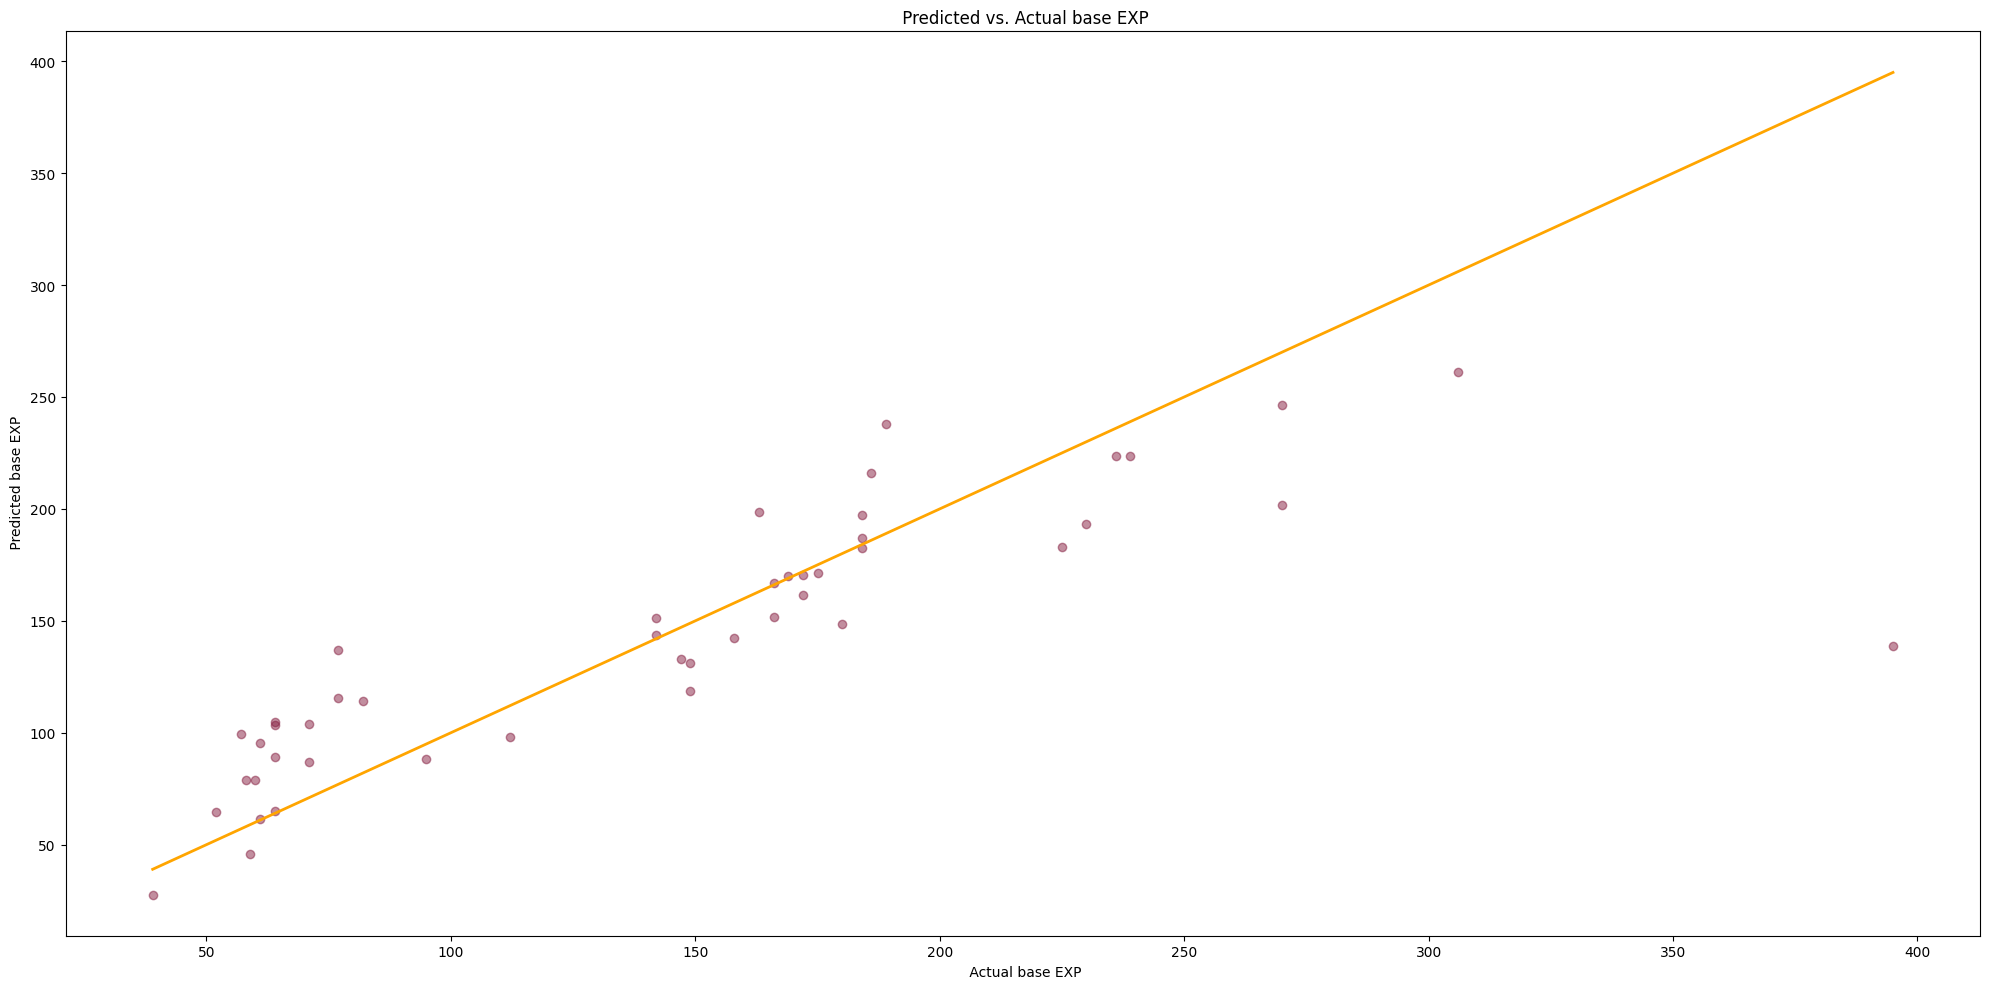

In [ ]:
#reference: sklearn cheatsheet (encoding categorical variables, regresssion models, regression metrics, complete regression workflow)
xTrainEncoder = pd.get_dummies(xTrain, columns=qualitativeColumn)
xTestEncoder = pd.get_dummies(xTest, columns=qualitativeColumn)
xTrainEncoder, xTestEncoder = xTrainEncoder.align(xTestEncoder, join='left', axis = 1, fill_value = 0)
model = LinearRegression()
model.fit(xTrainEncoder, yTrain)
yPredictor = model.predict(xTestEncoder)
r2 = r2_score(yTest, yPredictor)
rmse = np.sqrt(mean_squared_error(yTest, yPredictor))
print("r2: " + str(round(r2, 4)))
print("rmse: " + str(round(rmse, 4)))

coefficient = pd.Series(model.coef_, index=xTrainEncoder.columns)
print("coefficients:")
print(coefficient)

fig, ax = plt.subplots(figsize=(20,10))
ax.scatter(yTest, yPredictor, color='#861f41', alpha = 0.5)
ax.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], color='orange', linewidth=2)
ax.set_xlabel(' Actual base EXP')
ax.set_ylabel(' Predicted base EXP')
ax.set_title(' Predicted vs. Actual base EXP')
plt.tight_layout()
plt.savefig('Peot_multivariate.png')
plt.show()

# The overall model got and R2 of 0.6453, which is higher than the highest univariate model, special defense, that has an R2 0.5491, meaning the multivariate model improved my predictions
# Largest coefficients:
# - Ice type, electric type, and grass types had the biggest impact on the graphs with coefficients of 21.79, 15.32, and -16.42 respectively
# - Stats wise, special attack and attack were the biggest with a 0.95 and 0.75.
# Did anything surprise me based on my expectations?
# - id was -0.32 which did surprise me since I expected higher dex numbers would lead to more exp due to legendaries and pseudo-legendaries, who tend to have higher dex numbers.
#   - This is due to the fact that id is far less important compared to actual stats.
# What does this model tell me about base EXP?
# - Attack and special attack are the best predictors
# - Ice and electric tend to have a higher base EXP
# - Grass and fire tend to have a lower base EXP


In [ ]:
with open('Peot_stats.txt', 'w') as f:
  f.write('Kanto Pokedex PokeAPI graphical analysis \n')
  f.write('Describe results\n')
  f.write(df.describe(include='all').to_string())
  f.write('Dependent Variable\n')
  f.write('What is the DV?\n')
  f.write('Base Experience\n')
  f.write('Base EXP is the amount of EXP dropped when a pokemon is beaten in battle\n')
  f.write('I chose this because I felt it reflected the true value of a Pokemon, higher Evo tend to drop more and so do rare pokemon like legendaries, so I expect stats like attack and special_attack to be predictors.\n')
  f.write('\n')
  f.write("What are the IV's and what are the expectations?\n")
  f.write('HP, Attack, Defense, Special Attack, Special Defense, Weight, Height, ID, Primary Typing, and Secondary Typing.\n')
  f.write('HP: I think higher HP leads to more combat time meaning higher base experience. \n')
  f.write('Attack: I believe higher Attack usually means the pokemon is evolved or from a higher level area (in the games), which tend to have higher base experience.\n')
  f.write('Defense: I think the relationship will be weak but will exist, this is because defense is high on weaker pokemon like metapod, though there are strong pokemon that have high defense aswell.\n')
  f.write('Special attack: I believe higher Special Attack leads to higher base experience and will have a similar result to strength. \n')
  f.write('Special defense: I believe higher Special Defense leads to higher base experience and will have similar results to defense. \n ')
  f.write('Weight: I believe heavier pokemon are often stronger, meaning they would have a higher base experience, but there will be outliers like Ryhorn. \n')
  f.write('Height: I believe taller pokemon tend to be stronger therefore having a higher base experience. \n')
  f.write('ID: I believe pokemon who have higher ID numbers are going to have high base experience since legendary/mythical pokemon have larger ID numbers. \n')
  f.write('Primary Type: I think certain types on average have a higher base experience than others such as flying which is the typing of all the Kanto legendaries. \n')
  f.write('Secondary Type: I expect that Pokemon with two types tend to have a higher base experience than pokemon with only 1 type becuase 2 types add more versatility. \n')
  f.write(' \n')
  f.write('Skew findings\n')
  f.write('There were 3 variables that had a clear skew. \n')
  f.write('hp: skew was 2.31 which is a positive skew, most pokemon fall between approximately 10 and 100 hp with a few outliers. \n')
  f.write('weight: skew was 3.55 which is a positive skew, most pokemon fall between 0 and 1500 hectograms with a few outliers showing up between 2000 and 4500. \n')
  f.write('Height: skew was 4.66 which is a positive skew, most pokeemon are on the shorter side falling between 0 and 25 decimetres. \n')
  f.write(' \n')
  f.write('What are the Strongest Correlations? \n')
  f.write(' - The IV that lines up with the dependent variable most strongly correlated with base EXP is special defense, with a correlation of 0.72.\n ')
  f.write(' - There are no independent variables with a correlation |r| > 0.80 \n')
  f.write('\n')
  f.write('What are the univariate R² results and which IV predicted best? \n')
  f.write('Special Defense: R2 = 0.5491\n')
  f.write('HP: R2 = 0.4873\n')
  f.write('Special Attack: R2 = 0.2343\n')
  f.write('Attack: R2 = 0.1061\n')
  f.write('Weight: R2 = 0.0446\n')
  f.write('ID: R2 = 0.0278\n')
  f.write('Defense: R2 = -0.1371\n')
  f.write('Secondary Typing: R2 = -0.2268\n')
  f.write('Primary Typing: R2 = -0.2828\n')
  f.write('Height: R2 = -0.3338\n')
  f.write('Based on the results the highest predictor of base exp was special defense with an R2 of 0.5491. \n')
  f.write('\n')
  f.write('The multivariate models results and my interpretation. \n')
  f.write('r2 = 0.6453\n')
  f.write('RMSE = 46.6374\n')
  f.write('\n')
  f.write('Coefficients \n')
  f.write('HP = 0.4655\n')
  f.write('Attack = 0.7464\n')
  f.write('Defense = 0.4204\n')
  f.write('Special Attack = 0.9528\n')
  f.write('Special Defense = 0.6942\n')
  f.write('Weight = 0.0028\n')
  f.write('Height = 0.3262\n')
  f.write('ID = -0.3224\n')
  f.write('Primary: Bug =  6.7399\n')
  f.write('Primary: Dragon = 0.5633\n')
  f.write('Primary: Electric = 15.3166\n')
  f.write('Primary: Fairy = 5.546\n')
  f.write('Primary: Fighting = -1.5205\n')
  f.write('Primary: Fire = -14.5228\n')
  f.write('Primary: Ghost = 9.6363\n')
  f.write('Primary: Grass = -16.4193\n')
  f.write('Primary: Ground = -9.2213\n')
  f.write('Primary Ice = 21.7891\n')
  f.write('Primary: Normal = 9.3745\n')
  f.write('Primary: Poison= -8.3753\n')
  f.write('Primary: Psychic = -11.6545\n')
  f.write('Primary: Rock = 1.0195\n')
  f.write('Primary: Water = -8.2715\n')
  f.write('Double Typing = 0.5169\n')
  f.write('Single Typing = -0.5169\n')

